# Classificação de Anúncios com Árvores de Decisão 🌳


Neste laboratório, você irá treinar um modelo de Árvore de Decisão para identificar anúncios de celulares em uma plataforma de e-commerce. O objetivo é entender como funciona cada etapa, praticar a implementação e avaliar o desempenho do modelo.

Siga as orientações de cada etapa com atenção. Este laboratório pode ser desenvolvido em dupla!

## Etapa 1: Importação de Bibliotecas

- Importe as bibliotecas necessárias:
  - `pandas` e `numpy`
  - `seaborn` e `matplotlib.pyplot`
  - `train_test_split` de `sklearn.model_selection`
  - `DecisionTreeClassifier` e `plot_tree` de `sklearn.tree`
  - `classification_report`, `confusion_matrix` e `accuracy_score` de `sklearn.metrics`
  - `LabelEncoder` e `MinMaxScaler` de `sklearn.preprocessing`



In [19]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização de dados
import seaborn as sns
import matplotlib.pyplot as plt

# Divisão de dados
from sklearn.model_selection import train_test_split

# Modelo de Árvore de Decisão
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Avaliação de desempenho
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Pré-processamento
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

## Etapa 2: Carregamento do Dataset

- O dataset será baixado diretamente do Google Drive utilizando o pacote `gdown`.
- Execute a célula abaixo para:
 - Instalar o gdown (caso ainda não esteja instalado);
 - Baixar o arquivo `ecommerce.csv` do Google Drive;
 - Carregar o conteúdo do CSV em um DataFrame.

In [20]:
# Instalar o gdown (se ainda não estiver instalado)
#%pip install -q gdown

# Baixar o dataset do Google Drive
import gdown

# Baixando um dataset 'ecommerce.csv' no formato CSV
!gdown '1TstOONoaFxkyQY534DWJAdCqiR_u90xV'

Downloading...
From: https://drive.google.com/uc?id=1TstOONoaFxkyQY534DWJAdCqiR_u90xV
To: /home/leonardo/projects/ciencia_de_dados/aula05/ecommerce.csv
100%|██████████████████████████████████████| 6.48k/6.48k [00:00<00:00, 39.6MB/s]


In [21]:
# Utilize o pandas para ler o arquivo 'ecommerce.csv' e inspecionar os primeiros registros  
df = pd.read_csv('ecommerce.csv')
df.head(10)


,Plataforma,Descrição do Produto,Link,Preço,Target
0,Bing,Smartphone Samsung Galaxy S21,https://produto1_v0.com,3392,1
1,Mercado Livre,Carregador portátil 20000mAh,https://produto2_v0.com,5806,0
2,Google,iPhone 13 novo,https://produto3_v0.com,3845,1
3,Google,Película de vidro temperado,https://produto4_v0.com,5101,0
4,Bing,Celular Xiaomi Redmi Note 11,https://produto5_v0.com,5062,1
5,Bing,Fone de ouvido bluetooth,https://produto6_v0.com,4367,0
6,Bing,Samsung Galaxy A54 lançamento,https://produto7_v0.com,239,1
7,Bing,Capinha resistente para iPhone,https://produto8_v0.com,2490,1
8,Bing,Motorola Edge 30,https://produto9_v0.com,6199,1
9,Mercado Livre,Suporte para celular carro,https://produto10_v0.com,612,1


## Etapa 3: Análise Exploratória dos Dados

Nesta etapa, você fará uma exploração visual e estatística dos dados para entender melhor a estrutura do dataset antes de treinar o modelo.

### Verifique a estrutura dos dados

Comece examinando o tamanho do conjunto de dados e o tipo de informação que ele contém:
- Use `.shape` para ver quantas linhas (amostras) e colunas (variáveis) o dataset possui.
- Use `.info()` para verificar os tipos de dados de cada coluna.
- Use `.isnull().sum()` para identificar se existem valores ausentes (nulos) em alguma coluna.

In [22]:
dimDF = (0, 0) 
dimDF = df.shape

df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Plataforma            100 non-null    object
 1   Descrição do Produto  100 non-null    object
 2   Link                  100 non-null    object
 3   Preço                 100 non-null    int64 
 4   Target                100 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 4.0+ KB


Plataforma              0
Descrição do Produto    0
Link                    0
Preço                   0
Target                  0
dtype: int64

### Explore a distribuição da variável alvo (`Target`)
A variável `Target` indica se o anúncio é sobre celular (`1`) ou não (`0`). É importante verificar se temos um equilíbrio entre as classes.

Para isso, utilize:

- `sns.countplot(x='Target', data=df)`

Isso mostrará quantos anúncios são de celulares e quantos não são.

<Axes: xlabel='Target', ylabel='count'>

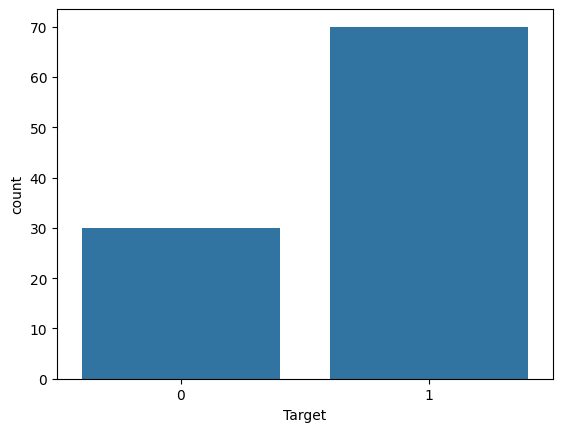

In [23]:
# Contagem de classes
sns.countplot(x='Target', data=df)

# contagem de celulares por plataforma separado por Target

# sns.countplot (x='Plataforma', hue='Target', data=df)

### Analise a distribuição dos preços

Visualizar como os preços estão distribuídos pode ajudar a identificar valores atípicos ou faixas de preços predominantes.

Use o seguinte comando para gerar um histograma com linha de densidade:
- `sns.histplot(df['Preço'], kde=True)`


[Text(0.5, 1.0, 'Distribuição dos Preços'),
 Text(0.5, 0, 'Preço'),
 Text(0, 0.5, 'Densidade')]

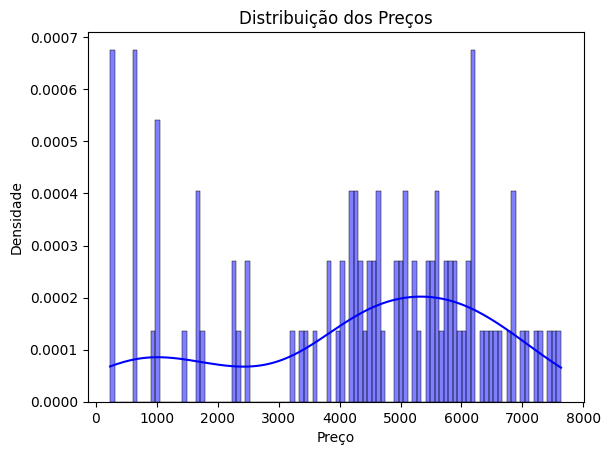

In [24]:
# Histograma do preço
sns.histplot (  
    df['Preço'], 
    kde= True,
    bins = 100,
    color = 'blue',
    stat = 'density'
).set ( 
    title = 'Distribuição dos Preços',
    xlabel = 'Preço',
    ylabel = 'Densidade'
)




### Relacione a plataforma com os tipos de anúncio

Vamos agora verificar em quais plataformas aparecem mais anúncios de celulares ou não celulares.

Para isso, crie um gráfico com:
- `sns.countplot(x='Plataforma', hue='Target', data=df)`


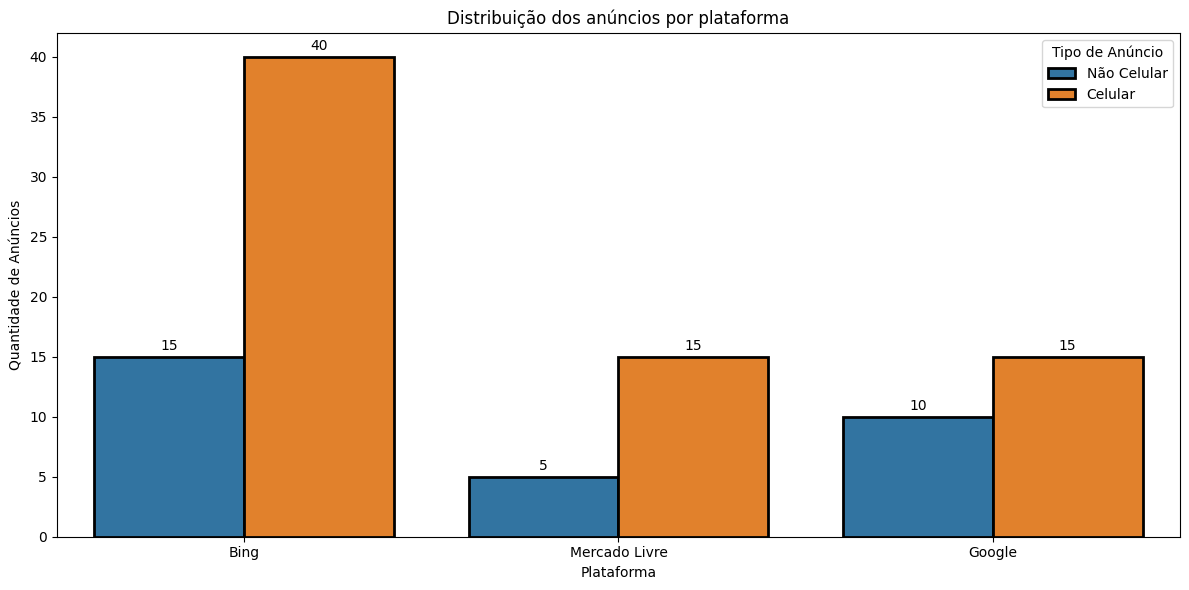

In [44]:
# Comparação por Plataforma
plt.figure (
    figsize = (12, 6)
)

sns.countplot (
    x = 'Plataforma', 
    hue = 'Target', 
    data = df,
     saturation = 0.75,
     edgecolor = 'black',
    linewidth = 2
).set (
    title = 'Distribuição dos anúncios por plataforma',
    xlabel = 'Plataforma',
    ylabel = 'Quantidade de Anúncios'
)

# adicionar legendas
plt.legend (
    title = 'Tipo de Anúncio',
    labels = ['Não Celular','Celular']
)

# adicionar valores sobre as barras
for i in plt.gca().containers:
    plt.gca().bar_label (i, padding = 3)

plt.tight_layout()

### Crie um mapa de calor de correlação

A correlação indica o quanto uma variável influencia a outra. Embora tenhamos poucas variáveis numéricas, ainda assim vale a pena verificar.

Para isso, use:

- `sns.heatmap(df.corr(), annot=True)`

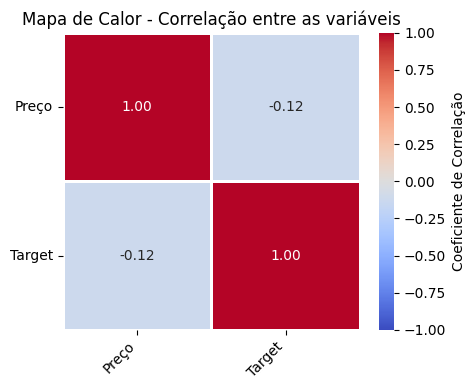

In [51]:
plt.figure ( figsize=(5,4) )

sns.heatmap (
    df.corr( numeric_only= True ),
    annot = True,
    cmap  = 'coolwarm',
    vmin = -1,
    vmax = 1,
    center = 0,
    fmt = '.2f',
    square = True,
    linewidths = 1,
    cbar_kws = { 'label' : 'Coeficiente de Correlação'}
).set (
    title = 'Mapa de Calor - Correlação entre as variáveis'    
)

# Rotacionar labels dos eixos para melhor legibilidade
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Ajustar layout
plt.tight_layout()

## Etapa 4: Pré-processamento dos dados

- Codifique a variável categórica `Plataforma` com `LabelEncoder`.
- Normalize a variável numérica `Preço` com `MinMaxScaler`.

In [ ]:
# Codificação da variável categórica
# Criar instância do LabelEncoder
le = LabelEncoder()

# Aplicar encoding na coluna 'Plataforma'
df['Plataforma'] = le.fit_transform(df['Plataforma'])

# Visualizar o mapeamento das categorias (opcional)
plataforma_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("\nMapeamento das Plataformas:")
for plataforma, valor in plataforma_mapping.items():
    print(f"{plataforma}: {valor}")

# Verificar resultado

# Os dois colchetes [[]] em df[['Plataforma']] têm propósitos diferentes:

# O primeiro colchete [...] é para acessar dados do DataFrame
# O segundo colchete ['Plataforma'] especifica que queremos retornar um DataFrame e não uma Series
# Diferença:

# df['Plataforma'] → retorna uma Series (uma única coluna)
# df[['Plataforma']] → retorna um DataFrame (mantém a estrutura de tabela)

print("\nPrimeiros registros após encoding:")
print(df[['Plataforma']].head())


# Normalização do preço
df['Preço'] = MinMaxScaler().fit_transform( df[['Preço']] )

#verificar resultado
print ('Primeiros registros apos normalização')
print ( df[['Preço']].head() )



Mapeamento das Plataformas:
0: 0
1: 1
2: 2

Primeiros registros após encoding:
   Plataforma
0           0
1           2
2           1
3           1
4           0
Primeiros registros apos normalização
      Preço
0  0.426717
1  0.753110
2  0.487966
3  0.657788
4  0.652515


## Etapa 5: Separação dos dados

Agora, separe as variáveis independentes (`X`) da variável alvo (`y`) e utilize `train_test_split` para dividir em conjuntos de treino e teste.



In [ ]:
#separar variáveis independentes (features, x) das variáveis dependentes (targets, y)
x = df[['Plataforma', 'Preço']] # DataFrame com 2 colchetes
y = df['Target'] # Series com 1 colchete

x_train, x_test, y_train, y_test = train_test_split (
    x,
    y,
    test_size= 0.2,
    random_state= 42,
    stratify= y
)

# Verificar dimensões
print(f"Tamanho total do dataset: {len(df)}")
print(f"Tamanho X_train: {len(x_train)}")
print(f"Tamanho X_test: {len(x_test)}")

# Verificar proporções das classes
print("\nProporção das classes:")
print("Dataset completo:", np.bincount(y) / len(y))
print("Conjunto de treino:", np.bincount(y_train) / len(y_train))
print("Conjunto de teste:", np.bincount(y_test) / len(y_test))

Tamanho total do dataset: 100
Tamanho X_train: 80
Tamanho X_test: 20

Proporção das classes:
Dataset completo: [0.3 0.7]
Conjunto de treino: [0.3 0.7]
Conjunto de teste: [0.3 0.7]


## Etapa 6: Treinamento do modelo

Treine o modelo de Árvore de Decisão com os dados de treino.




Importância das features:
      Feature  Importancia
1       Preço      0.86686
0  Plataforma      0.13314


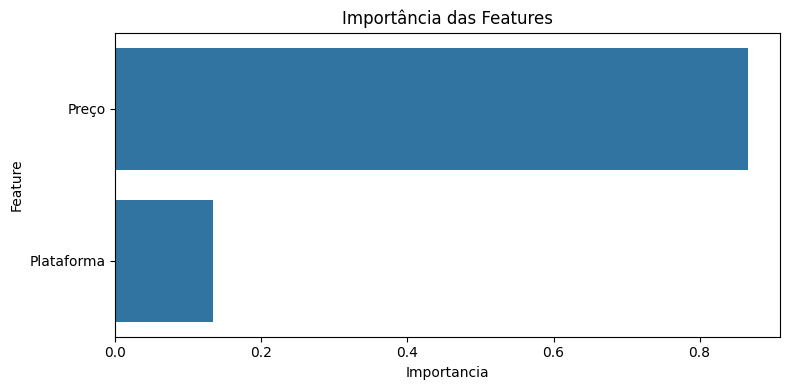

In [ ]:
#criar e treinar o modelo
modelo = DecisionTreeClassifier (
    max_depth= 5,           # Profundidade máxima da árvore
    min_samples_split= 20,  # Número mínimo de amostras para dividir um nó
    min_samples_leaf= 5,    # Número mínimo de amostras em um nó folha
    random_state= 42        # Semente aleatória para reprodutibilidade
)

#treinar o modelo com os dados de treino
modelo.fit( x_train, y_train)

#verificar a importância das features
importancia_features = pd.DataFrame(
    {
        'Feature': x_train.columns,
        'Importancia': modelo.feature_importances_
    }
) 
# Ordenar por importância
importancia_features = importancia_features.sort_values('Importancia', ascending=False)

# Visualizar
print("\nImportância das features:")
print(importancia_features)

# # Criar gráfico
# plt.figure(figsize=(8, 4))
# sns.barplot(
#     data=importancia_features,
#     x='Importancia',
#     y='Feature'
# ).set(title='Importância das Features')
# plt.tight_layout()

### Visualize a estrutura da árvore

- Plote a árvore de decisão treinada por meio do `plot_tree`.
- Observe quais atributos foram mais importantes e qual a profundidade da árvore.

Obs: Use `plot_tree(seu_modelo, filled=True, feature_names=X.columns, class_names=rotulos_classes)` para desenhar a árvore.


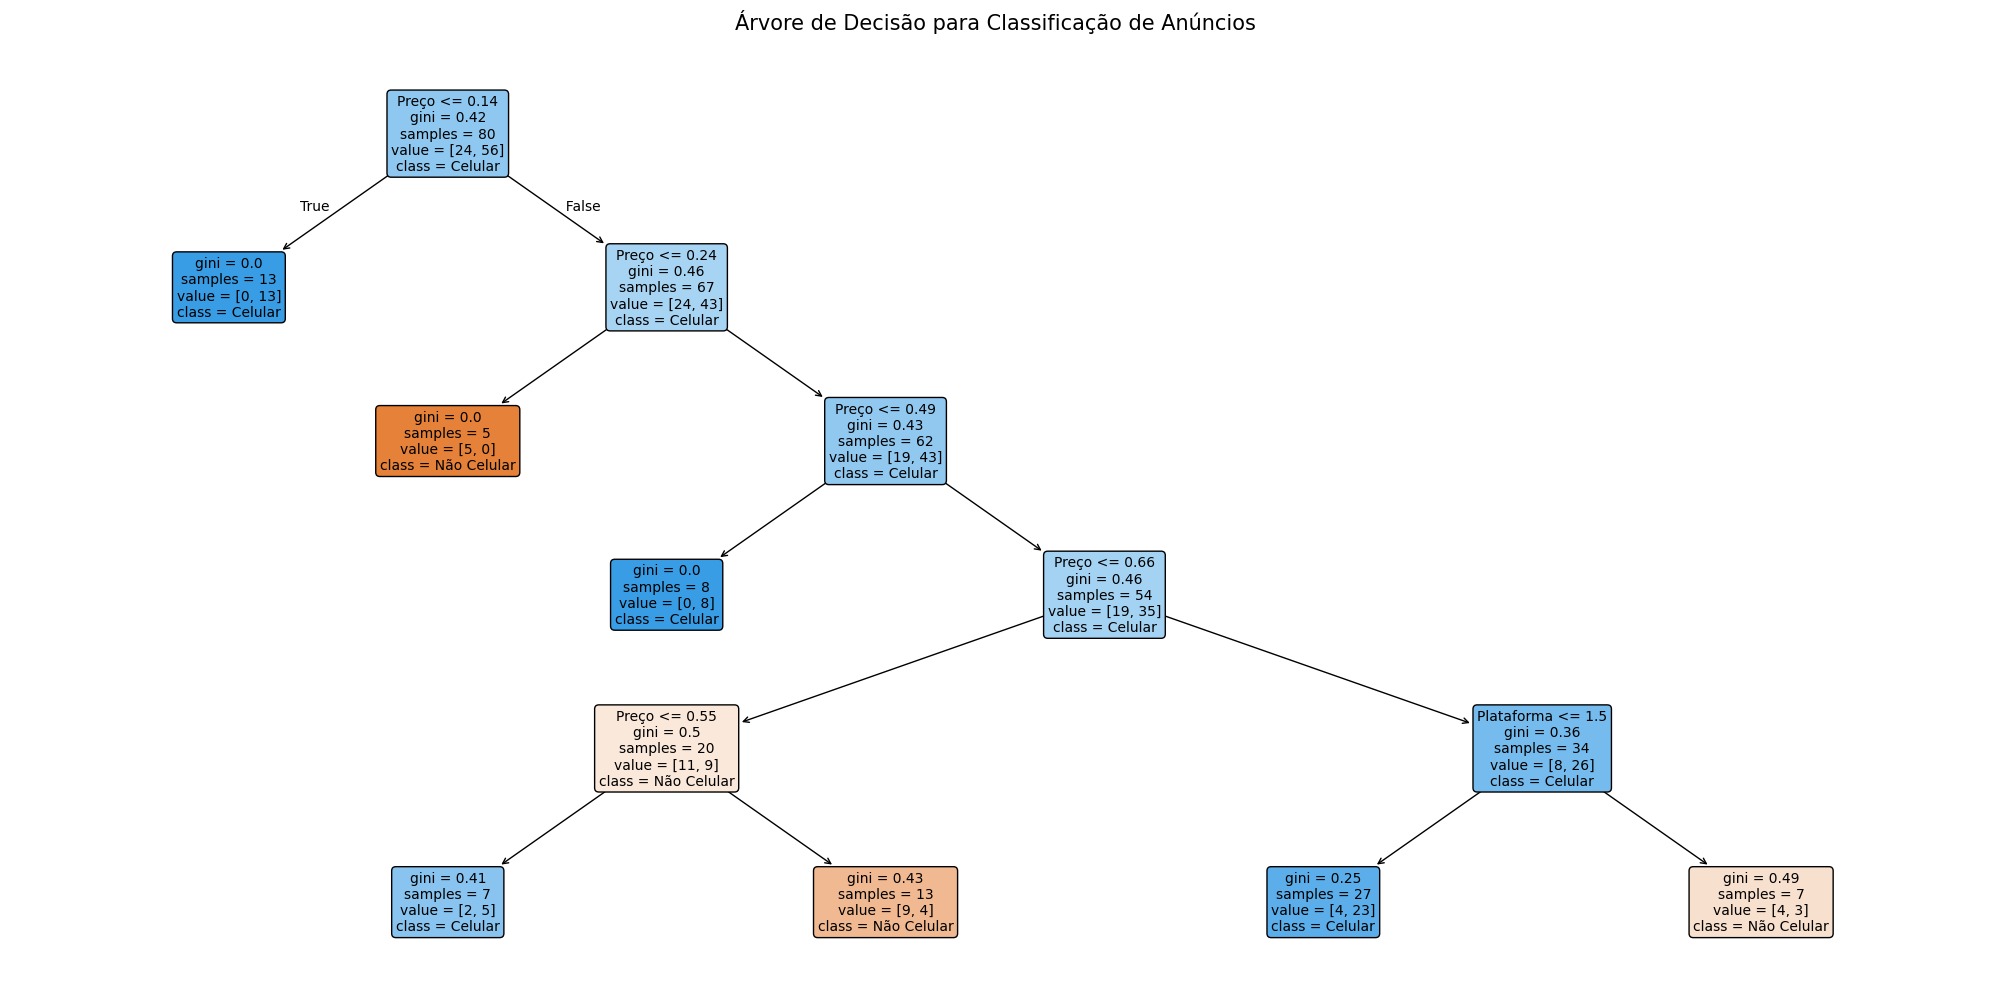

In [64]:
# Configurar o tamanho da figura para melhor visualização
plt.figure( figsize=(20, 10) )

#plotar a árvore com o parametro customizado
plot_tree (
    decision_tree= modelo,
    feature_names=x_train.columns,
    class_names=['Não Celular', 'Celular'],
    filled= True,
    rounded= True,
    fontsize= 10,
    precision= 2
)

plt.title ('Árvore de Decisão para Classificação de Anúncios', pad = 20, size = 15)
plt.tight_layout()
plt.show()


## Etapa 7: Realização de Previsões com o Modelo

Agora que o modelo foi treinado, vamos utilizá-lo para realizar previsões sobre o conjunto de teste (`X_test`). Para isso, usamos o método `.predict()` da árvore de decisão:

In [69]:
# Realizar previsões
y_pred = modelo.predict( x_test )



## Etapa 8: Avaliação do Desempenho do Modelo


Com as previsões armazenadas em `y_pred`, vamos avaliar o desempenho do modelo utilizando as seguintes métricas:

- Acurácia: representa a proporção de acertos do modelo.
- Matriz de Confusão: mostra como o modelo se saiu para cada classe (celular e não celular).
- Relatório de Classificação: inclui precisão, recall e F1-score para cada classe.

In [ ]:
# Comparar as primeiras previsões com os valores reais
print("Comparação das primeiras 10 previsões:")
print("\nValores Reais:", y_test[:10].values)
print("Valores Preditos:", y_pred[:10])

# Calcular acurácia do modelo
acuracia = accuracy_score(y_test, y_pred)
print(f"\nAcurácia do modelo: {acuracia:.2%}")

matriz_confusao = confusion_matrix ( y_test, y_pred )

# Gerar relatório de classificação
print("\nRelatório de Classificação:")
print( classification_report(
    y_test, 
    y_pred, 
    target_names=['Não Celular', 'Celular'])
)



Comparação das primeiras 10 previsões:

Valores Reais: [1 1 1 1 0 1 0 1 0 0]
Valores Preditos: [1 1 1 1 0 0 0 1 1 1]

Acurácia do modelo: 75.00%

Relatório de Classificação:
              precision    recall  f1-score   support

 Não Celular       0.57      0.67      0.62         6
     Celular       0.85      0.79      0.81        14

    accuracy                           0.75        20
   macro avg       0.71      0.73      0.72        20
weighted avg       0.76      0.75      0.75        20



## Etapa 9: Visualização Gráfica das Métricas

Agora que avaliamos o modelo com números, vamos visualizar os resultados de forma gráfica. Isso ajuda a interpretar o desempenho do modelo de forma mais clara e intuitiva.

A matriz de confusão mostra quantas previsões foram corretas e incorretas para cada classe:
- A diagonal principal representa os acertos.
- Os valores fora da diagonal indicam erros de classificação.

Para visualizar, utilize o `seaborn.heatmap`.

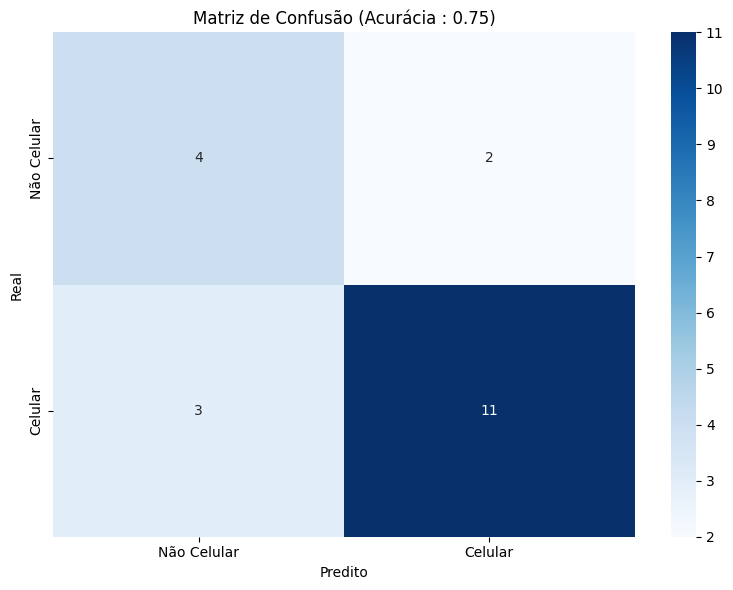

In [76]:
plt.figure (figsize= (8,6))
sns.heatmap (
    matriz_confusao,
    annot= True,
    fmt = 'd', #formato inteiro
    cmap = 'Blues', #esquema de cores
    xticklabels=['Não Celular', 'Celular'],
    yticklabels=['Não Celular', 'Celular']
).set (
    title = f'Matriz de Confusão (Acurácia : {acuracia:.2f})',
    xlabel = 'Predito',
    ylabel = 'Real'
)

plt.tight_layout()
plt.show()

### Métricas por Classe (Gráfico de Barras)

Vamos visualizar, para cada classe (Celular e Não Celular), os seguintes indicadores:
- Precisão (Precision): quantos dos itens classificados como positivos realmente são positivos.
-  Revocação (Recall): quantos dos itens positivos foram corretamente identificados.
-  F1-score: média harmônica entre precisão e recall.

Para isso, utilize `matplotlib.pyplot` para gerar um gráfico de barras com as três métricas lado a lado para cada classe.


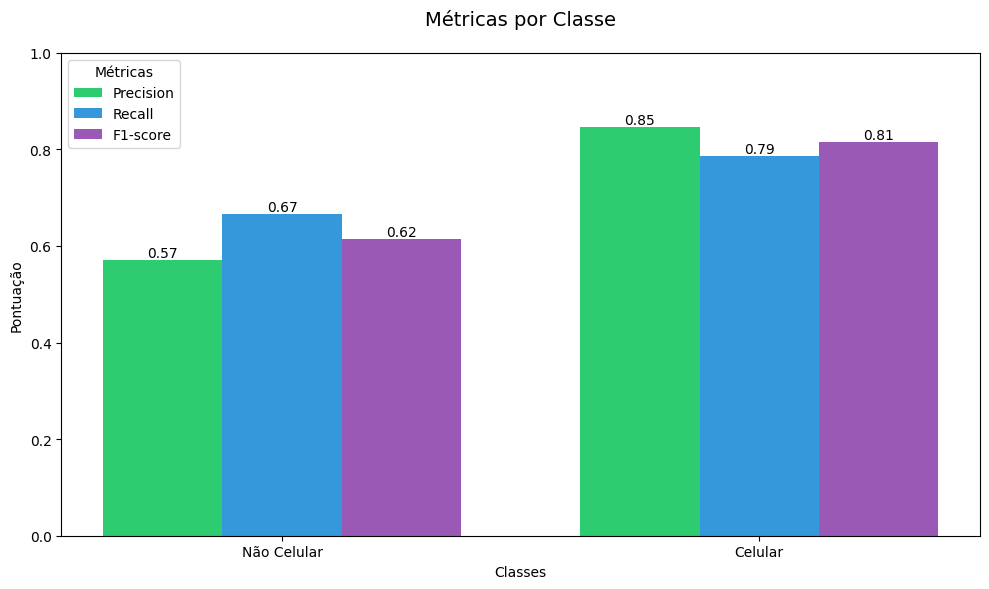

In [78]:
relatorio = classification_report (
    y_test,
    y_pred,
    target_names= ['Não Celular', 'Celular'],
    output_dict= True
)

#preparar os dados para o grafico
classes = ['Não Celular', 'Celular']
metricas = ['precision', 'recall', 'f1-score']
cores = ['#2ecc71', '#3498db', '#9b59b6']  # Verde, Azul, Roxo

#criar figura
plt.figure (figsize=(10, 6))

#posições das barras
x = np.arange( len( classes ) )
largura = 0.25 #largura as barras

for i, metrica in enumerate (metricas):
    valores = [ relatorio[classe][metrica] for classe in classes ]
    plt.bar ( x + i*largura, valores, largura, label= metrica.capitalize(), color=cores[i])

#customizar o gráfico
plt.title ('Métricas por Classe', pad=20, size=14)
plt.xlabel ('Classes')
plt.ylabel ('Pontuação')
plt.ylim (0, 1)
plt.xticks ( x + largura, classes )
plt.legend (title = 'Métricas')

#adicionar valores sobre as barras
for i, metrica in enumerate( metricas ):
    valores = [ relatorio[classe][metrica] for classe in classes ]
    for j, valor in enumerate( valores ):
        plt.text (
            j + i*largura, 
            valor,
            f'{valor:.2f}',
            ha = 'center', va = 'bottom'
        )

plt.tight_layout()
plt.show()